<h1>Image Classification using Logistic Regression</h1>

<h2>Installations</h2>

In [3]:
%pip install torch torchvision numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [4]:
import torch 
import torchvision
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transform
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

<h2>Importing Data</h2>

In [6]:
dataset = MNIST(root="data/", download=True)

In [7]:
len(dataset)

60000

In [8]:
test_dataset = MNIST(root="data/", train=False)
len(test_dataset)

10000

In [9]:
dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

Label 5


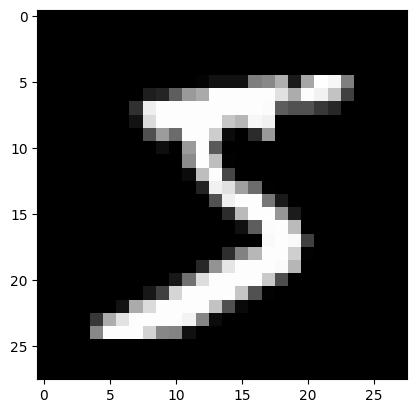

In [10]:
image, label = dataset[0]
plt.imshow(image, cmap="gray")
print("Label", label)

Label 3


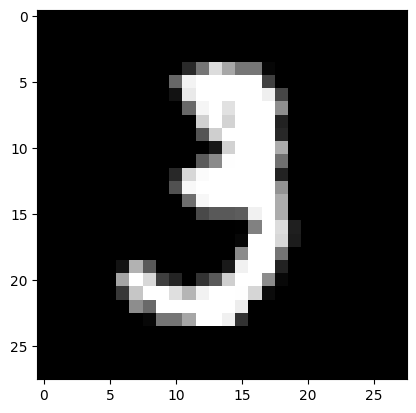

In [11]:
image, label = dataset[10]
plt.imshow(image, cmap="gray")
print("Label", label)

In [12]:
dataset = MNIST(root="data/", train=True, transform=transform.ToTensor())

In [13]:
img_tensor, label = dataset[0]
print(img_tensor.shape, label)

torch.Size([1, 28, 28]) 5


In [14]:
print(img_tensor[:,10:15,10:15])
print(torch.max(img_tensor), torch.min(img_tensor))

tensor([[[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
         [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
         [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
         [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
         [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]]])
tensor(1.) tensor(0.)


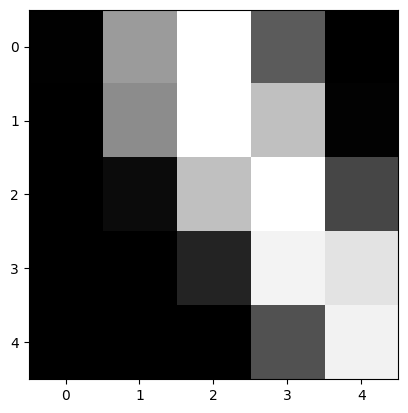

In [15]:
plt.imshow(img_tensor[0,10:15, 10:15], cmap="gray")

<h2>Training and Validation</h2>

In [17]:
def split_indices(n, val_pct):
    #Determine size of validation set
    n_val = int(val_pct*n)
    #Create random permutautions of 0 to n-1
    idxs = np.random.permutation(n)
    #Pick first n_val indices from validation set
    return idxs[n_val:], idxs[:n_val]

In [18]:
train_indices, val_indices = split_indices(n=len(dataset), val_pct=0.2)

In [19]:
print(len(train_indices), len(val_indices))
print("Sample val indices:", val_indices[:20])

48000 12000
Sample val indices: [50218 42713 15181 19949 55739    24 57132 27656 24964 52965 57581 19558
   782 24615 55166 10171 17907 42363 39537 22912]


In [20]:
batch_size=100

train_sampler = SubsetRandomSampler(train_indices)
train_loader = DataLoader(dataset,
                          batch_size,
                          sampler=train_sampler)

val_sampler = SubsetRandomSampler(val_indices)
val_loader = DataLoader(dataset,
                          batch_size,
                          sampler=val_sampler)

<h2>Model</h2>

In [22]:
import torch.nn as nn

input_size = 28*28
num_classes = 10

model = nn.Linear(input_size, num_classes)

In [23]:
print(model.weight.shape)
model.weight

torch.Size([10, 784])


Parameter containing:
tensor([[-0.0015,  0.0182, -0.0086,  ...,  0.0033,  0.0297, -0.0023],
        [-0.0260, -0.0162, -0.0353,  ...,  0.0188,  0.0062,  0.0137],
        [-0.0256, -0.0210,  0.0304,  ..., -0.0111, -0.0196, -0.0255],
        ...,
        [-0.0207,  0.0027, -0.0294,  ...,  0.0130, -0.0080, -0.0244],
        [ 0.0261,  0.0353,  0.0194,  ...,  0.0202,  0.0283, -0.0026],
        [-0.0197, -0.0072, -0.0272,  ...,  0.0102,  0.0209,  0.0200]],
       requires_grad=True)

In [24]:
print(model.bias.shape)
model.bias

torch.Size([10])


Parameter containing:
tensor([-0.0340,  0.0022,  0.0050,  0.0113,  0.0069, -0.0347,  0.0015,  0.0162,
         0.0139, -0.0138], requires_grad=True)

In [25]:
for images, labels in train_loader:
    print(label)
    print(images.shape)
    # outputs=model(images)
    break

5
torch.Size([100, 1, 28, 28])


In [26]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out

model = MnistModel()

In [27]:
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[ 0.0337,  0.0240, -0.0288,  ...,  0.0031,  0.0060,  0.0184],
         [-0.0032, -0.0345,  0.0173,  ...,  0.0048, -0.0164,  0.0326],
         [ 0.0050,  0.0145,  0.0235,  ...,  0.0117,  0.0314, -0.0321],
         ...,
         [ 0.0129, -0.0085, -0.0054,  ...,  0.0111,  0.0047,  0.0239],
         [-0.0007, -0.0048,  0.0109,  ..., -0.0333,  0.0091,  0.0269],
         [ 0.0242, -0.0294, -0.0309,  ...,  0.0262, -0.0173,  0.0331]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0084, -0.0127,  0.0041,  0.0273,  0.0295, -0.0111,  0.0202, -0.0130,
          0.0024, -0.0266], requires_grad=True)]

In [28]:
for images, label in train_loader:
    outputs = model(images)
    break

print("output shape:", outputs.shape)
print("Sample output:\n", outputs[:2].data)

output shape: torch.Size([100, 10])
Sample output:
 tensor([[-3.6573e-01,  4.4715e-01, -8.1081e-02,  1.9660e-01,  2.3563e-01,
         -1.2013e-01, -2.9685e-01, -6.7157e-02, -7.8797e-03,  3.2917e-05],
        [-1.7419e-01,  4.1295e-01,  5.2588e-02,  6.4809e-02,  2.3915e-01,
         -2.3650e-01,  3.3479e-01,  2.2741e-01, -6.8087e-02, -3.1272e-02]])


### Error Correction using Softmax

In [30]:
import torch.nn.functional as F

In [31]:
probs = F.softmax(outputs, dim=1)

print("Sample probabilities:\n", probs[:2].data)
print("Sum:", torch.sum(probs[0]).item())

Sample probabilities:
 tensor([[0.0679, 0.1530, 0.0902, 0.1191, 0.1238, 0.0868, 0.0727, 0.0915, 0.0971,
         0.0979],
        [0.0758, 0.1363, 0.0951, 0.0962, 0.1146, 0.0712, 0.1260, 0.1132, 0.0842,
         0.0874]])
Sum: 1.0


In [32]:
max_prob, preds = torch.max(probs, dim=1)
print(preds)
print(max_prob)

tensor([1, 1, 3, 1, 3, 4, 1, 8, 3, 1, 1, 4, 1, 8, 1, 1, 4, 4, 0, 1, 4, 3, 3, 3,
        4, 3, 3, 3, 6, 8, 4, 0, 9, 4, 8, 4, 3, 8, 0, 1, 3, 1, 3, 3, 8, 7, 3, 4,
        1, 1, 4, 3, 8, 1, 4, 8, 1, 4, 3, 4, 8, 1, 1, 1, 4, 4, 3, 4, 4, 7, 3, 0,
        7, 8, 1, 3, 7, 3, 1, 3, 4, 4, 1, 3, 9, 1, 3, 1, 4, 1, 3, 8, 4, 4, 8, 4,
        1, 1, 3, 8])
tensor([0.1530, 0.1363, 0.1245, 0.1080, 0.1223, 0.1221, 0.1321, 0.1293, 0.1385,
        0.1314, 0.1501, 0.1237, 0.1417, 0.1413, 0.1230, 0.1372, 0.1365, 0.1171,
        0.1277, 0.1403, 0.1218, 0.1273, 0.1298, 0.1294, 0.1160, 0.1242, 0.1271,
        0.1383, 0.1189, 0.1268, 0.1277, 0.1198, 0.1316, 0.1396, 0.1426, 0.1264,
        0.1181, 0.1226, 0.1105, 0.1199, 0.1443, 0.1365, 0.1296, 0.1391, 0.1304,
        0.1302, 0.1328, 0.1203, 0.1322, 0.1231, 0.1427, 0.1232, 0.1258, 0.1215,
        0.1273, 0.1295, 0.1345, 0.1201, 0.1239, 0.1221, 0.1269, 0.1447, 0.1611,
        0.1272, 0.1387, 0.1501, 0.1180, 0.1510, 0.1383, 0.1198, 0.1237, 0.1217,
        0.1270, 0.1

In [33]:
labels

tensor([3, 6, 0, 1, 6, 6, 2, 8, 6, 2, 0, 1, 3, 2, 3, 8, 7, 7, 9, 3, 6, 9, 5, 1,
        3, 3, 6, 9, 1, 6, 7, 0, 8, 8, 5, 7, 8, 6, 6, 7, 8, 3, 9, 1, 9, 9, 4, 0,
        3, 2, 6, 5, 6, 2, 2, 1, 7, 4, 6, 3, 8, 6, 4, 7, 4, 1, 6, 9, 9, 2, 8, 3,
        3, 2, 9, 1, 7, 7, 4, 1, 1, 0, 6, 6, 2, 5, 9, 5, 3, 1, 4, 3, 1, 6, 9, 9,
        1, 7, 3, 3])

### Evaluation Metric and Loss Function

In [35]:
labels == preds

tensor([False, False, False,  True, False, False, False,  True, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False, False, False, False,
        False,  True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False,  True, False, False,
         True, False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False, False,  True,
        False, False, False, False, False, False,  True, False,  True, False])

In [36]:
def accuracy(preds, label):
    return torch.sum(labels == preds).item() / len(preds)

In [37]:
accuracy(preds, labels)

0.11

In [38]:
loss_fn = F.cross_entropy

In [39]:
loss = loss_fn(outputs, preds)
loss

tensor(2.0390, grad_fn=<NllLossBackward0>)

### Optimizer 

In [41]:
learning = 0.001

optimizer = torch.optim.SGD(model.parameters(), lr=learning)

## Training the model

In [43]:
def loss_batch(model, loss_func, xb, yb, opt=None, metric=None):
    #Calculate Loss
    pred = model(xb)
    loss = loss_func(pred, yb)

    if opt is not None:
        #Compute Gradients
        loss.backward()
        #Update Parameter
        opt.step()
        #Reset Gradient
        opt.zero_grad()

    metric_result = None
    if metric is not None:
        metric_result = metric(pred, yb)

    return loss.item(), len(xb), metric_result

In [44]:
def evaluate(model, loss_fn, valid_dl, metric=None):
    with torch.no_grad():
        #Pass each batch through the model
        result = [loss_batch(model, loss_fn, xb, yb, metric=metric)
                   for xb, yb in valid_dl]
        #Seprate losses, counts and metrics
        losses, nums, metrics = zip(*result)
        #Total size of data
        total = np.sum(nums)
        #Avg. loss across batches
        avg_loss = np.sum(np.multiply(losses, nums)) / total
        avg_metric = None
        if metric is not None:
            avg_metric = np.sum(np.multiply(metrics, nums)) / total
            
        return avg_loss, total, avg_metric

In [45]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.sum(preds == labels) / len(preds)

In [46]:
val_loss, total, val_acc = evaluate(model, loss_fn, val_loader, metric=accuracy)
print("Loss: {:.4f}, Accuracy: {:.4f}".format(val_loss, val_acc))

Loss: 2.3221, Accuracy: 0.0863


In [47]:
def fit (epochs, model, loss_fn, opt, train_dl, valid_dl, metric=None):
    for epoch in range(epochs):
        #Training 
        for xb, yb in train_dl:
            loss,_,_ = loss_batch(model, loss_fn, xb, yb, opt)

        #Evaluation
        result = evaluate(model, loss_fn, valid_dl, metric)
        val_loss, total, val_metric = result

        #Print progress
        if metric is None:
            print("Epoch[{}/{}], Loss{:.4f}: ".format(epoch+1, epochs, val_loss))
        else:
            print("Epoch[{}/{}], Loss{:.4f}: , {}: {:.4f}: ".format(epoch+1, epochs, val_loss, metric.__name__, val_metric))

In [48]:
model = MnistModel()
optimizer = torch.optim.SGD(model.parameters(), lr=learning)

In [49]:
epoch1 = fit(5, model, F.cross_entropy, optimizer, train_loader, val_loader, accuracy)

Epoch[1/5], Loss1.8882: , accuracy: 0.6415: 
Epoch[2/5], Loss1.5875: , accuracy: 0.7573: 
Epoch[3/5], Loss1.3758: , accuracy: 0.7903: 
Epoch[4/5], Loss1.2232: , accuracy: 0.8057: 
Epoch[5/5], Loss1.1100: , accuracy: 0.8154: 


In [50]:
epoch2 = fit(5, model, F.cross_entropy, optimizer, train_loader, val_loader, accuracy)

Epoch[1/5], Loss1.0234: , accuracy: 0.8244: 
Epoch[2/5], Loss0.9550: , accuracy: 0.8301: 
Epoch[3/5], Loss0.8999: , accuracy: 0.8346: 
Epoch[4/5], Loss0.8546: , accuracy: 0.8380: 
Epoch[5/5], Loss0.8165: , accuracy: 0.8408: 


In [51]:
epoch3 =  fit(5, model, F.cross_entropy, optimizer, train_loader, val_loader, accuracy)

Epoch[1/5], Loss0.7841: , accuracy: 0.8436: 
Epoch[2/5], Loss0.7561: , accuracy: 0.8456: 
Epoch[3/5], Loss0.7318: , accuracy: 0.8481: 
Epoch[4/5], Loss0.7103: , accuracy: 0.8497: 
Epoch[5/5], Loss0.6912: , accuracy: 0.8510: 


In [52]:
epoch4 = fit(5, model, F.cross_entropy, optimizer, train_loader, val_loader, accuracy)

Epoch[1/5], Loss0.6742: , accuracy: 0.8535: 
Epoch[2/5], Loss0.6588: , accuracy: 0.8550: 
Epoch[3/5], Loss0.6448: , accuracy: 0.8567: 
Epoch[4/5], Loss0.6321: , accuracy: 0.8586: 
Epoch[5/5], Loss0.6205: , accuracy: 0.8595: 


Text(0.5, 1.0, 'Epoch vs Accuracy')

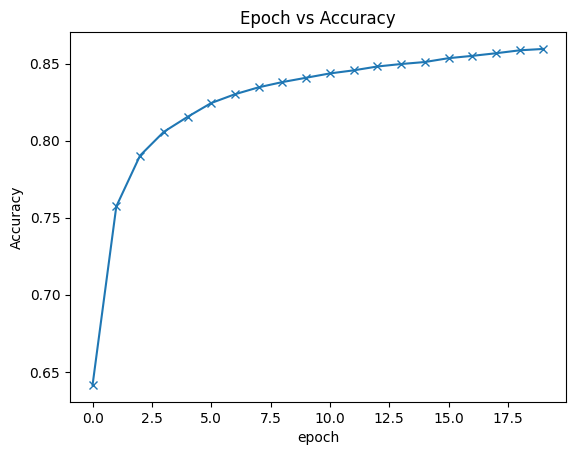

In [105]:
accuracies = [0.6415, 0.7573, 0.7903, 0.8057, 0.8154,
              0.8244, 0.8301, 0.8346, 0.8380, 0.8408,
              0.8436, 0.8456, 0.8481, 0.8497, 0.8510,
              0.8535, 0.8550, 0.8567, 0.8586, 0.8595]

plt.plot(accuracies, "-x")
plt.xlabel("epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Accuracy")

## Test with Test Dataset

In [112]:
test_dataset = MNIST(root="data/",
                     train=False,
                     transform=transform.ToTensor())

Shape:  torch.Size([1, 28, 28])
Label:  7


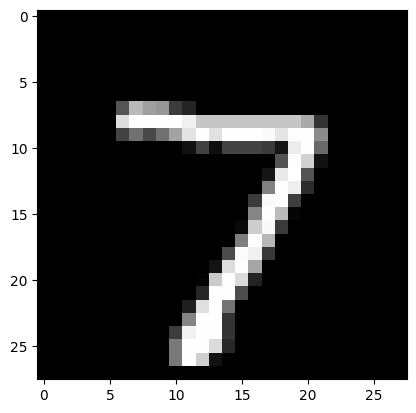

In [122]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap="gray")
print("Shape: ", img.shape)
print("Label: ", label)

In [136]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _,preds = torch.max(yb, dim=1)
    return preds[0].item()

Label:  7 ,Predicted:  7


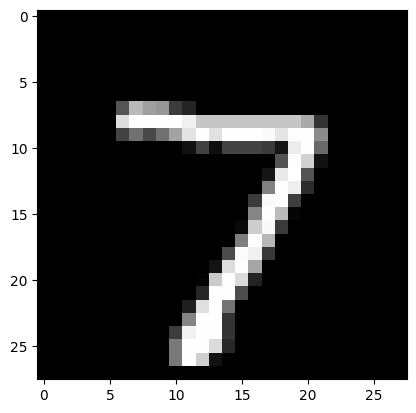

In [138]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap="gray")
print("Label: ", label, ",Predicted: ", predict_image(img[0], model))

Label:  0 ,Predicted:  0


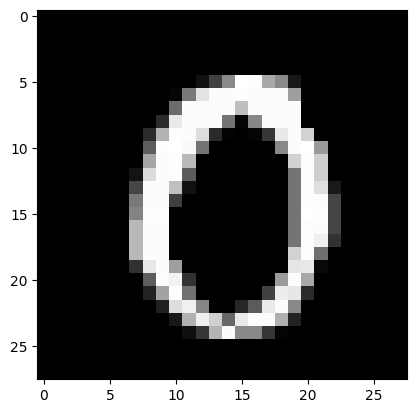

In [140]:
img, label = test_dataset[13]
plt.imshow(img[0], cmap="gray")
print("Label: ", label, ",Predicted: ", predict_image(img[0], model))

Label:  9 ,Predicted:  3


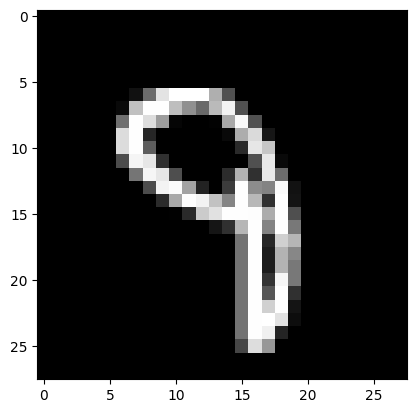

In [146]:
img, label = test_dataset[193]
plt.imshow(img[0], cmap="gray")
print("Label: ", label, ",Predicted: ", predict_image(img[0], model))

Label:  8 ,Predicted:  8


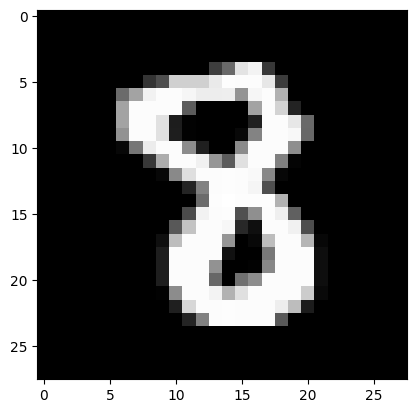

In [148]:
img, label = test_dataset[1893]
plt.imshow(img[0], cmap="gray")
print("Label: ", label, ",Predicted: ", predict_image(img[0], model))

In [150]:
test_loader = DataLoader(test_dataset, batch_size=200)

test_loss, total, test_acc = evaluate(model, loss_fn, test_loader, accuracy)
print("Loss: {:.4f}, Accuracy: {:.4f}".format(test_loss, test_acc))

Loss: 0.5976, Accuracy: 0.8698
